        CUSTOMER CHURN VISUAL ANALYSIS

Dataset Loaded Successfully!

FIRST FIVE RECORDS


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,True,False,True,False,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,True,False,False,False,False,True,False
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,True,False,False,True,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,False,False,True,False,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,False,True,False,True,False,True


DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   SeniorCitizen                          7043 non-null   int64  
 1   tenure                                 7043 non-null   int64  
 2   MonthlyCharges                         7043 non-null   float64
 3   TotalCharges                           7043 non-null   float64
 4   gender_Male                            7043 non-null   bool   
 5   Partner_Yes                            7043 non-null   bool   
 6   Dependents_Yes                         7043 non-null   bool   
 7   PhoneService_Yes                       7043 non-null   bool   
 8   MultipleLines_No phone service         7043 non-null   bool   
 9   MultipleLines_Yes                      7043 non-null   bool   
 10  InternetService_Fiber optic            7043 non-null

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2281.916928
std,0.368612,24.559481,30.090047,2265.270398
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,402.225000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


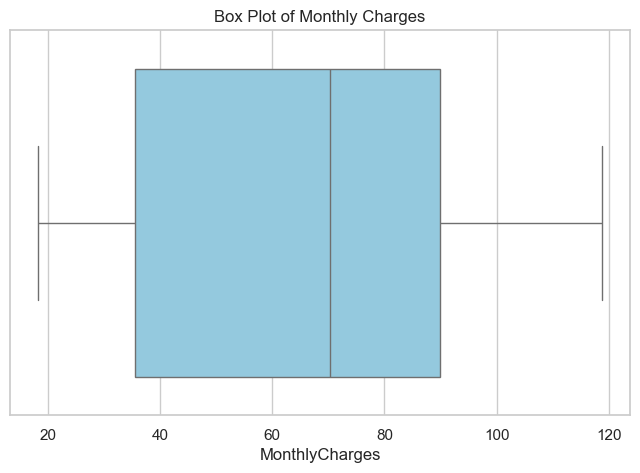

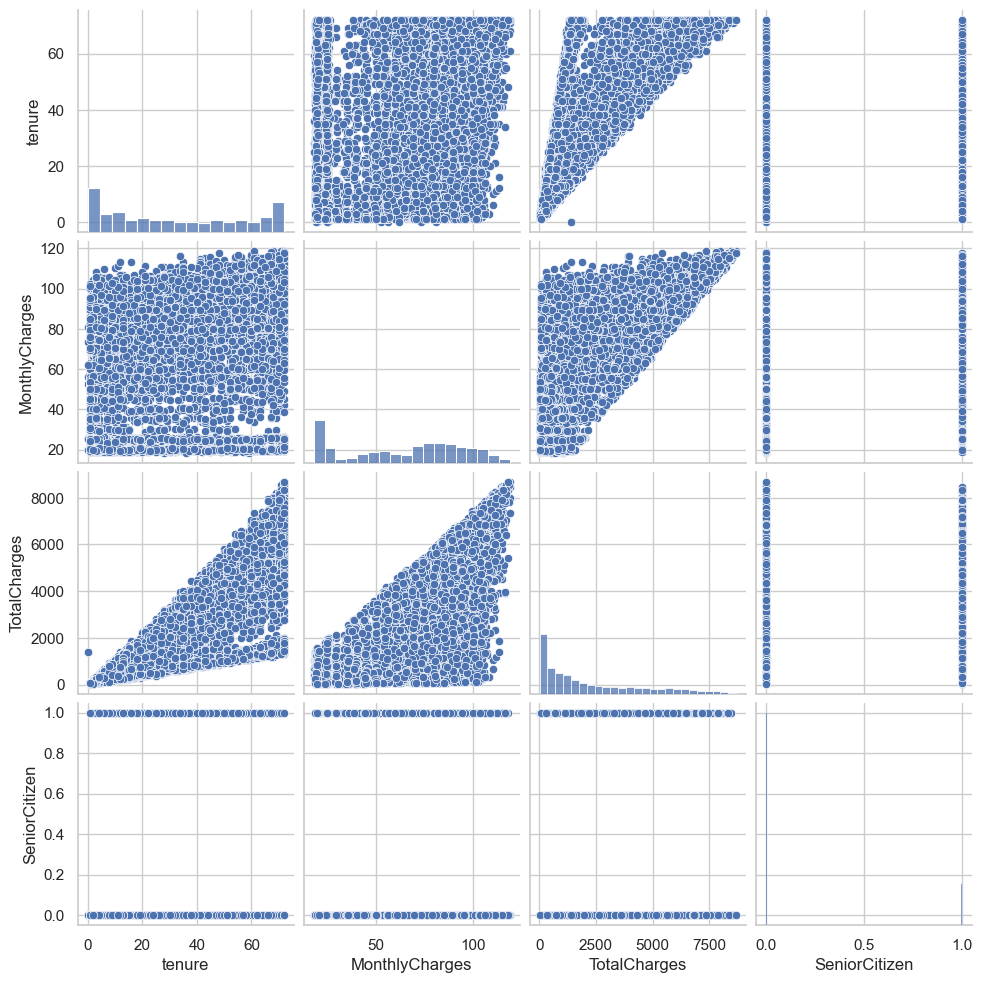

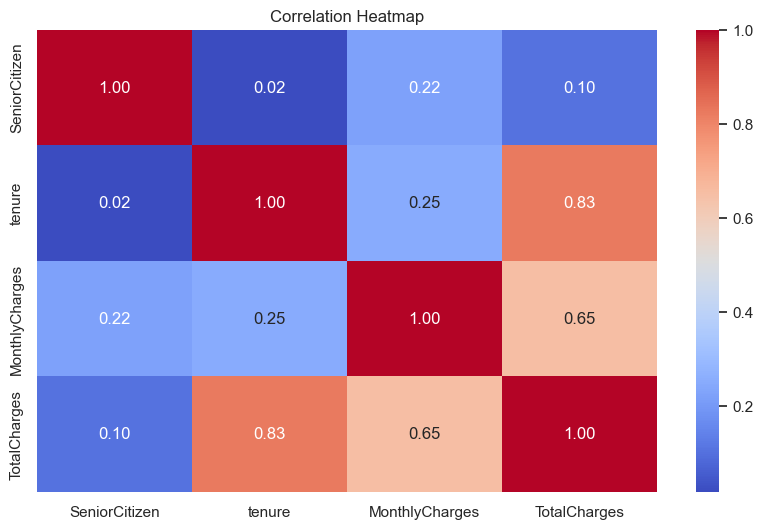

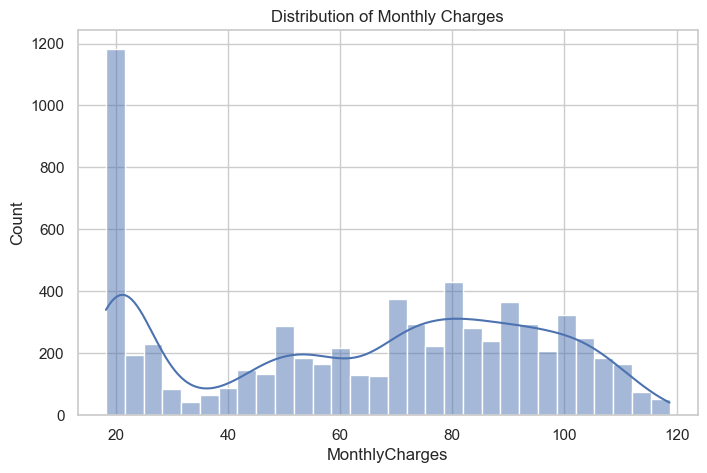

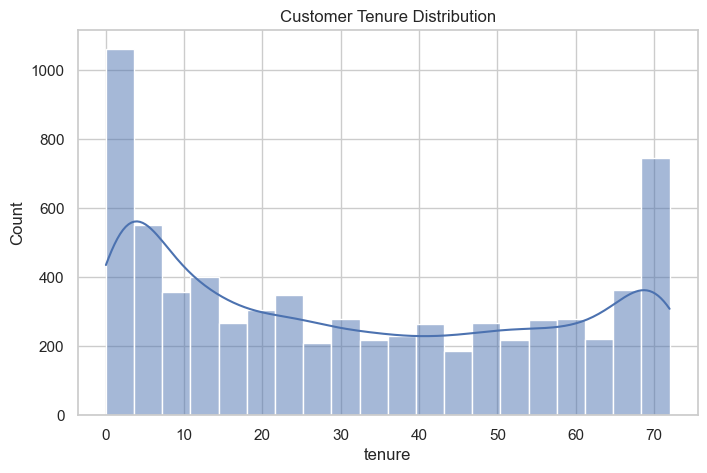

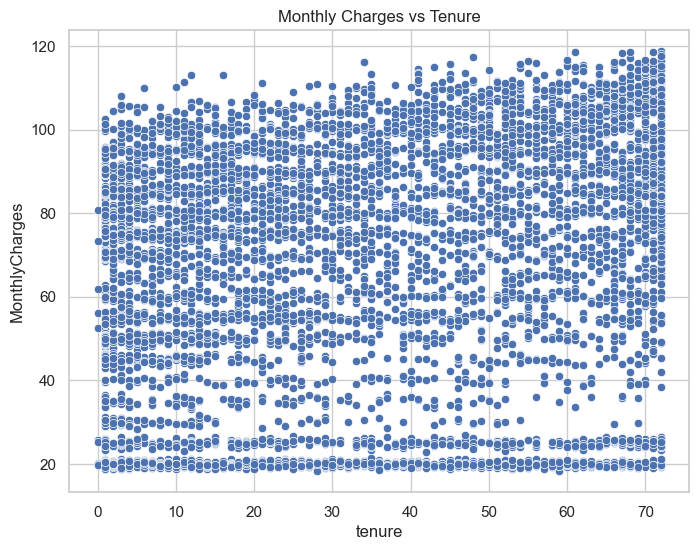

FINAL SUMMARY
Total Records              : 7043
Total Features             : 31
Average Monthly Charges    : 64.76
Average Tenure             : 32.37

Visualizations Saved Successfully!

Saved Files:
✔ boxplot.png
✔ violinplot.png
✔ pairplot.png
✔ heatmap.png
✔ histogram.png
✔ countplot.png
✔ tenure_distribution.png
✔ scatterplot.png

Output Folder : output/

PROJECT COMPLETED SUCCESSFULLY


In [2]:
# ============================================================
#            CUSTOMER CHURN VISUAL ANALYSIS
# ============================================================

import os
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

# Create output folder
os.makedirs("output", exist_ok=True)

print("="*60)
print("        CUSTOMER CHURN VISUAL ANALYSIS")
print("="*60)

# ------------------------------------------------------------
# Load Dataset
# ------------------------------------------------------------
df = pd.read_csv("Cleaned_Telco_Customer_Churn.csv")

# Convert TotalCharges if needed
if "TotalCharges" in df.columns:
    df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

print("\nDataset Loaded Successfully!\n")

print("="*60)
print("FIRST FIVE RECORDS")
print("="*60)
display(df.head())

print("="*60)
print("DATASET INFORMATION")
print("="*60)
print(df.info())

print("="*60)
print("STATISTICAL SUMMARY")
print("="*60)
display(df.describe())

# ------------------------------------------------------------
# Box Plot
# ------------------------------------------------------------
plt.figure(figsize=(8,5))
sns.boxplot(x=df["MonthlyCharges"], color="skyblue")
plt.title("Box Plot of Monthly Charges")
plt.savefig("output/boxplot.png", dpi=300, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# Violin Plot
# ------------------------------------------------------------
if "Churn" in df.columns:
    plt.figure(figsize=(8,5))
    sns.violinplot(x="Churn", y="MonthlyCharges", data=df)
    plt.title("Monthly Charges by Churn")
    plt.savefig("output/violinplot.png", dpi=300, bbox_inches="tight")
    plt.show()

# ------------------------------------------------------------
# Pair Plot
# ------------------------------------------------------------
pair_cols=[]

for c in ["tenure","MonthlyCharges","TotalCharges","SeniorCitizen"]:
    if c in df.columns:
        pair_cols.append(c)

if len(pair_cols)>=2:
    pair=sns.pairplot(df[pair_cols].dropna())
    pair.savefig("output/pairplot.png", dpi=300)
    plt.show()

# ------------------------------------------------------------
# Correlation Heatmap
# ------------------------------------------------------------
plt.figure(figsize=(10,6))

numeric=df.select_dtypes(include=np.number)

sns.heatmap(
    numeric.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.savefig("output/heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# Histogram
# ------------------------------------------------------------
plt.figure(figsize=(8,5))
sns.histplot(df["MonthlyCharges"], bins=30, kde=True)
plt.title("Distribution of Monthly Charges")
plt.savefig("output/histogram.png", dpi=300, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# Count Plot
# ------------------------------------------------------------
if "Churn" in df.columns:
    plt.figure(figsize=(7,5))
    sns.countplot(x="Churn", data=df)
    plt.title("Customer Churn Count")
    plt.savefig("output/countplot.png", dpi=300, bbox_inches="tight")
    plt.show()

# ------------------------------------------------------------
# Tenure Distribution
# ------------------------------------------------------------
if "tenure" in df.columns:
    plt.figure(figsize=(8,5))
    sns.histplot(df["tenure"], bins=20, kde=True)
    plt.title("Customer Tenure Distribution")
    plt.savefig("output/tenure_distribution.png", dpi=300, bbox_inches="tight")
    plt.show()

# ------------------------------------------------------------
# Scatter Plot
# ------------------------------------------------------------
if "tenure" in df.columns:
    plt.figure(figsize=(8,6))
    sns.scatterplot(
        x="tenure",
        y="MonthlyCharges",
        data=df
    )
    plt.title("Monthly Charges vs Tenure")
    plt.savefig("output/scatterplot.png", dpi=300, bbox_inches="tight")
    plt.show()

# ------------------------------------------------------------
# Final Summary
# ------------------------------------------------------------
print("="*60)
print("FINAL SUMMARY")
print("="*60)

print(f"Total Records              : {len(df)}")
print(f"Total Features             : {df.shape[1]}")

if "Churn" in df.columns:
    print(f"Customers Churned          : {(df['Churn']=='Yes').sum()}")
    print(f"Customers Retained         : {(df['Churn']=='No').sum()}")

print(f"Average Monthly Charges    : {df['MonthlyCharges'].mean():.2f}")

if "tenure" in df.columns:
    print(f"Average Tenure             : {df['tenure'].mean():.2f}")

print("\nVisualizations Saved Successfully!")

print("\nSaved Files:")
print("✔ boxplot.png")
print("✔ violinplot.png")
print("✔ pairplot.png")
print("✔ heatmap.png")
print("✔ histogram.png")
print("✔ countplot.png")
print("✔ tenure_distribution.png")
print("✔ scatterplot.png")

print("\nOutput Folder : output/")
print("\nPROJECT COMPLETED SUCCESSFULLY")
print("="*60)